# Responsible Machine Learning & Fairness Auditing for Neuroimaging: A Practical Open Science Case Study
**IEEE MLSP 2026 Tutorial**  
Victoria McCray, MSc | mccray.v@northeastern.edu

---

## Research Question
Can a classifier trained on neuroimaging quality metrics distinguish clinical from control participants — and does it perform equitably across demographic subgroups?

## Dataset
Wogu, Filima, Caron et al. (2025). *A labeled Clinical-MRI dataset of Nigerian brains.* Scientific Data, 12, 518.  
https://doi.org/10.1038/s41597-025-04743-0

**Data access:** https://doi.org/10.25663/brainlife.pub.61 (requires brainlife.io account + Data Use Agreement)

---

## Block 1: Setup
Install and import required libraries.

In [1]:
# Run once to install dependencies
!pip install aif360 scikit-learn matplotlib seaborn pandas numpy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## Block 2: Load Participants Data

Participant demographics are drawn directly from the published dataset (Wogu et al., 2025),  
hosted in the tutorial materials repo for reproducibility.

**Full MRIQC quality metrics** (CNR, SNR, etc.) are available via brainlife.io after signing the DUA:  
https://doi.org/10.25663/brainlife.pub.61  
Until then, quality metrics are simulated based on ranges reported in the paper (Figure 3).

### Note on MRIQC Data Access

The full MRIQC quality metrics for this dataset are generated by running 
the MRIQC pipeline (Esteban et al., 2017) on the raw NIfTI images via 
brainlife.io. The pipeline script is available at:
https://github.com/brainlife/app-mriqc

Access to the processed outputs requires:
1. A brainlife.io account
2. Signing the Data Use Agreement at https://doi.org/10.25663/brainlife.pub.61
3. Project membership (request via the project page)

Until access is granted, this notebook uses simulated quality metrics 
based on the CNR ranges reported in Figure 3 of Wogu et al. (2025).
To swap in real data, replace the simulation block with:

    mriqc_df = pd.read_csv('path/to/regressors.tsv', sep='\t')

In [3]:
# Load participants data
# Option A: from GitHub (after uploading to repo)
# url = 'https://raw.githubusercontent.com/victoriamccray/Hackathon/main/tutorial/nigerian_brain_participants.tsv'
# df = pd.read_csv(url, sep='\t')

# Option B: local file (use this until uploaded to GitHub)
df = pd.read_csv('nigerian_brain_participants.tsv', sep='\t')

# Standardise column names
df = df.rename(columns={'ClincalGroup': 'diagnosis'})
df['SES'] = df['SES'].replace('n/a', None)

print(f'Shape: {df.shape}')
print(f'\nDiagnosis counts:')
print(df['diagnosis'].value_counts())
print(f'\nColumns: {df.columns.tolist()}')
df.head()

Shape: (88, 7)

Diagnosis counts:
Control      35
Dementia     31
Parkinson    22
Name: diagnosis, dtype: int64

Columns: ['participant_id', 'sex', 'age', 'diagnosis', 'SES', 'Education', 'GeopoliticalRegion']


,participant_id,sex,age,diagnosis,SES,Education,GeopoliticalRegion
0,sub-01,F,15,Control,middle,secondary,South-South
1,sub-02,M,36,Control,middle,tertiary,South-South
2,sub-03,M,18,Control,middle,secondary,South-South
3,sub-04,M,49,Control,upper,tertiary,South-South
4,sub-05,M,41,Control,middle,secondary,South-South


In [4]:
# Simulate MRIQC quality metrics based on paper Figure 3 (CNR ranges)
# Replace this block with real regressors.tsv data after brainlife.io DUA sign-off
np.random.seed(42)
n = len(df)

# Scanner strength affects image quality — key ethical variable in this dataset
# 3 sites: RSUTH (1.5T), Intercontinental (0.3T), LifeBridge (1.5T)
# North-Central participants were scanned at LifeBridge (1.5T)
scanner = np.where(
    df['GeopoliticalRegion'] == 'North-Central',
    '1.5T',
    np.random.choice(['1.5T', '0.3T'], n, p=[0.70, 0.30])
)
df['scanner'] = scanner

# CNR: Contrast-to-Noise Ratio — higher = better image quality
# 1.5T scanners produce substantially higher CNR than 0.3T
df['cnr_t1w'] = np.where(
    df['scanner'] == '1.5T',
    np.random.normal(2.0, 0.5, n).clip(0.5, 3.5),
    np.random.normal(0.8, 0.3, n).clip(0.1, 1.5)
)
df['cnr_t2w'] = np.where(
    df['scanner'] == '1.5T',
    np.random.normal(1.8, 0.4, n).clip(0.5, 3.0),
    np.random.normal(0.7, 0.3, n).clip(0.1, 1.4)
)
df['snr_t1w'] = df['cnr_t1w'] * np.random.uniform(1.5, 2.5, n)

print('Simulated MRIQC metrics added.')
print(f"Scanner distribution:\n{df['scanner'].value_counts()}")
df[['participant_id', 'diagnosis', 'scanner', 'cnr_t1w', 'cnr_t2w']].head()

Simulated MRIQC metrics added.
Scanner distribution:
1.5T    72
0.3T    16
Name: scanner, dtype: int64


,participant_id,diagnosis,scanner,cnr_t1w,cnr_t2w
0,sub-01,Control,1.5T,1.963995,2.001995
1,sub-02,Control,0.3T,0.585695,0.430824
2,sub-03,Control,0.3T,1.359732,0.722741
3,sub-04,Control,1.5T,1.677440,1.666200
4,sub-05,Control,1.5T,2.180698,1.610022


---
## Block 3: Demographic Exploration & Ethical Checkpoint 1

Before any modelling, understand who is in the dataset and what structural imbalances exist.

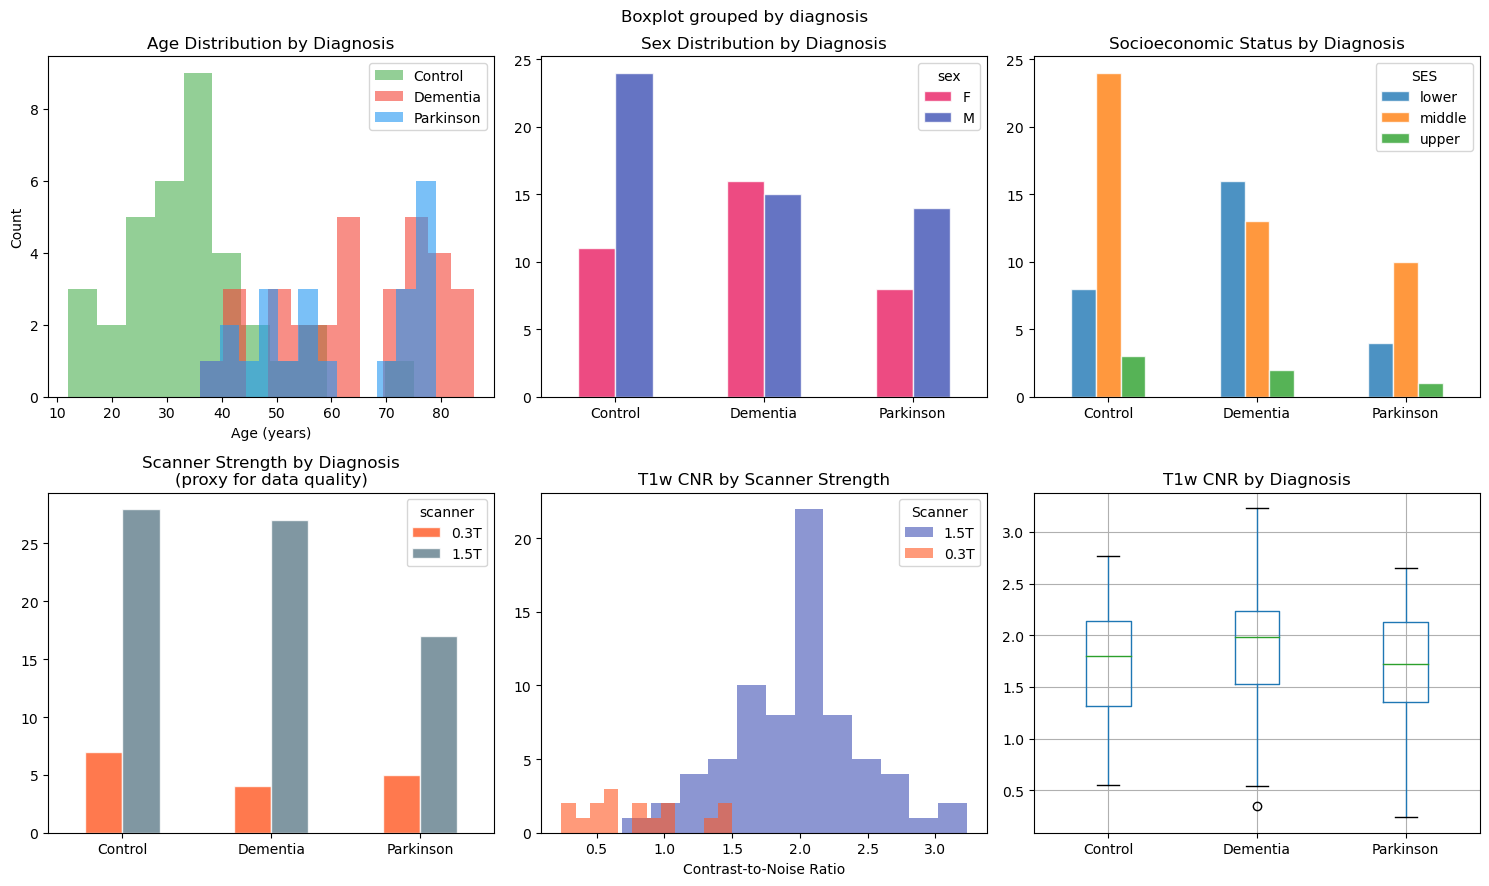

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Nigerian Brain MRI Dataset — Demographic & Quality Overview',
             fontsize=14, fontweight='bold')

palette = {'Control': '#4CAF50', 'Dementia': '#F44336', 'Parkinson': '#2196F3'}

# Age distribution
ax = axes[0, 0]
for group, color in palette.items():
    ax.hist(df[df['diagnosis'] == group]['age'], alpha=0.6,
            label=group, color=color, bins=12)
ax.set_title('Age Distribution by Diagnosis')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Count')
ax.legend()

# Sex breakdown
ax = axes[0, 1]
df.groupby(['diagnosis', 'sex']).size().unstack(fill_value=0).plot(
    kind='bar', ax=ax, color=['#E91E63', '#3F51B5'], alpha=0.8, edgecolor='white')
ax.set_title('Sex Distribution by Diagnosis')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)

# SES breakdown
ax = axes[0, 2]
ses_order = ['lower', 'middle', 'upper']
ses_counts = df.groupby(['diagnosis', 'SES']).size().unstack(fill_value=0)
ses_counts = ses_counts.reindex(columns=[c for c in ses_order if c in ses_counts.columns], fill_value=0)
ses_counts.plot(kind='bar', ax=ax, alpha=0.8, edgecolor='white')
ax.set_title('Socioeconomic Status by Diagnosis')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)

# Scanner distribution
ax = axes[1, 0]
df.groupby(['diagnosis', 'scanner']).size().unstack(fill_value=0).plot(
    kind='bar', ax=ax, color=['#FF5722', '#607D8B'], alpha=0.8, edgecolor='white')
ax.set_title('Scanner Strength by Diagnosis\n(proxy for data quality)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)

# CNR by scanner
ax = axes[1, 1]
for scanner_type, color in [('1.5T', '#3F51B5'), ('0.3T', '#FF5722')]:
    ax.hist(df[df['scanner'] == scanner_type]['cnr_t1w'],
            alpha=0.6, label=scanner_type, color=color, bins=12)
ax.set_title('T1w CNR by Scanner Strength')
ax.set_xlabel('Contrast-to-Noise Ratio')
ax.legend(title='Scanner')

# CNR by diagnosis
ax = axes[1, 2]
df.boxplot(column='cnr_t1w', by='diagnosis', ax=ax)
ax.set_title('T1w CNR by Diagnosis')
ax.set_xlabel('')
plt.sca(ax)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Ethical Checkpoint 1: What structural imbalances do you see?

**1. Age confound**  
Controls are ~30 years younger on average than clinical groups (mean 34 vs 61-65).  
Any classifier may learn age rather than diagnosis — these variables are entangled.

**2. Scanner bias**  
0.3T scanners produce substantially lower CNR than 1.5T.  
If scanner site correlates with diagnosis group, a model may learn "poor image = clinical patient."

**3. Sample size**  
n=88 is small. Fairness metrics on subgroups as small as 8 participants have wide confidence intervals.

> *Discussion: What would you need to fix these issues? Is algorithmic mitigation sufficient, or is the problem upstream?*

---
## Block 4: AIF360 Dataset Preparation & Ethical Checkpoint 2

Define the classification task and protected attributes **before** any modelling.  
These are deliberate, value-laden choices — not technical defaults.

In [6]:
from aif360.datasets import BinaryLabelDataset

# Binary label: Clinical (PD or Dementia) = 1, Control = 0
# Note: collapsing PD and Dementia is a simplification for teaching purposes
df['label'] = (df['diagnosis'] != 'Control').astype(int)

# Protected attribute: sex
# Male = 1 (privileged — majority in control group at 69%)
# Female = 0 (unprivileged)
df['sex_binary'] = (df['sex'] == 'M').astype(int)

# Protected attribute: scanner strength
# 1.5T = 1 (privileged — higher quality data)
# 0.3T = 0 (unprivileged)
df['scanner_binary'] = (df['scanner'] == '1.5T').astype(int)

feature_cols = ['cnr_t1w', 'cnr_t2w', 'snr_t1w', 'age']
protected_col = 'sex_binary'

df_aif = df[feature_cols + [protected_col, 'label']].copy()

aif_dataset = BinaryLabelDataset(
    df=df_aif,
    label_names=['label'],
    protected_attribute_names=[protected_col],
    favorable_label=0,    # favorable = Control (healthy)
    unfavorable_label=1
)

print('AIF360 dataset created.')
print(f'Features: {feature_cols}')
print(f'Protected attribute: sex (1=Male, 0=Female)')
print(f'Favorable label: 0 (Control)')

AIF360 dataset created.
Features: ['cnr_t1w', 'cnr_t2w', 'snr_t1w', 'age']
Protected attribute: sex (1=Male, 0=Female)
Favorable label: 0 (Control)


### Ethical Checkpoint 2: Design decisions encode values

Why is 'Control' the **favorable** label?  
In AIF360, favorable means the outcome we want more people to receive.  
For a screening tool, being correctly identified as healthy is the favorable outcome —  
misclassifying a healthy person as clinical leads to unnecessary intervention.

> *There is no neutral framing. Document and justify these choices explicitly in your work.*

---
## Block 5: Pre-Modelling Bias Detection

In [7]:
from aif360.metrics import BinaryLabelDatasetMetric

privileged_groups   = [{'sex_binary': 1}]
unprivileged_groups = [{'sex_binary': 0}]

metric = BinaryLabelDatasetMetric(
    aif_dataset,
    privileged_groups=privileged_groups,
    unprivileged_groups=unprivileged_groups
)

di  = metric.disparate_impact()
spd = metric.statistical_parity_difference()

print('=== PRE-MODELLING BIAS METRICS (Sex) ===')
print(f'Disparate Impact:              {di:.3f}  (1.0 = perfect parity, <0.8 = US 80% rule threshold)')
print(f'Statistical Parity Difference: {spd:.3f}  (0.0 = perfect parity)')

# Also audit for scanner bias
df_scanner = df[feature_cols + ['scanner_binary', 'label']].copy()
aif_scanner = BinaryLabelDataset(
    df=df_scanner, label_names=['label'],
    protected_attribute_names=['scanner_binary'],
    favorable_label=0, unfavorable_label=1
)
metric_s = BinaryLabelDatasetMetric(
    aif_scanner,
    privileged_groups=[{'scanner_binary': 1}],
    unprivileged_groups=[{'scanner_binary': 0}]
)
print(f'\n=== PRE-MODELLING BIAS METRICS (Scanner) ===')
print(f'Disparate Impact (1.5T vs 0.3T): {metric_s.disparate_impact():.3f}')
print(f'Statistical Parity Difference:   {metric_s.statistical_parity_difference():.3f}')

pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


=== PRE-MODELLING BIAS METRICS (Sex) ===
Disparate Impact:              0.694  (1.0 = perfect parity, <0.8 = US 80% rule threshold)
Statistical Parity Difference: -0.139  (0.0 = perfect parity)

=== PRE-MODELLING BIAS METRICS (Scanner) ===
Disparate Impact (1.5T vs 0.3T): 1.125
Statistical Parity Difference:   0.049


### Ethical Checkpoint 3: Small samples & false precision

These numbers look precise. They are not.

With n=88 and subgroups as small as 8 participants, fairness metrics have very wide confidence intervals.  
A disparate impact of 0.78 could easily be 0.60 or 1.00 with a different random sample.

**Responsible practice:**
- Report confidence intervals alongside point estimates
- Be explicit about sample size limitations  
- Treat this as hypothesis-generating, not hypothesis-confirming

---
## Block 6: Classifier & Post-Modelling Fairness

Train a simple classifier, then evaluate **accuracy AND fairness together**.  
The key lesson: accuracy alone does not tell you whether a model is equitable.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from aif360.metrics import ClassificationMetric

X = df[feature_cols].values
y = df['label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_scaled, y, df.index,
    test_size=0.3, random_state=42, stratify=y
)

clf = LogisticRegression(random_state=42, max_iter=500)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print('=== CLASSIFIER PERFORMANCE ===')
print(classification_report(y_test, y_pred, target_names=['Control', 'Clinical']))

# Build AIF360 evaluation datasets
df_test = df.loc[idx_test][feature_cols + ['sex_binary', 'label']].copy()
df_pred = df_test.copy()
df_pred['label'] = y_pred

aif_test = BinaryLabelDataset(df=df_test, label_names=['label'],
    protected_attribute_names=['sex_binary'], favorable_label=0, unfavorable_label=1)
aif_pred = BinaryLabelDataset(df=df_pred, label_names=['label'],
    protected_attribute_names=['sex_binary'], favorable_label=0, unfavorable_label=1)

clf_metric = ClassificationMetric(
    aif_test, aif_pred,
    privileged_groups=privileged_groups,
    unprivileged_groups=unprivileged_groups
)

print('=== POST-MODELLING FAIRNESS METRICS ===')
print(f'Equal Opportunity Difference: {clf_metric.equal_opportunity_difference():.3f}  (0.0 = equal TPR across groups)')
print(f'Average Odds Difference:      {clf_metric.average_odds_difference():.3f}  (0.0 = equal TPR+FPR across groups)')
print(f'TPR Male:   {clf_metric.true_positive_rate(privileged=True):.3f}')
print(f'TPR Female: {clf_metric.true_positive_rate(privileged=False):.3f}')

=== CLASSIFIER PERFORMANCE ===
              precision    recall  f1-score   support

     Control       0.69      1.00      0.81        11
    Clinical       1.00      0.69      0.81        16

    accuracy                           0.81        27
   macro avg       0.84      0.84      0.81        27
weighted avg       0.87      0.81      0.81        27

=== POST-MODELLING FAIRNESS METRICS ===
Equal Opportunity Difference: 0.000  (0.0 = equal TPR across groups)
Average Odds Difference:      -0.117  (0.0 = equal TPR+FPR across groups)
TPR Male:   1.000
TPR Female: 1.000


---
## Block 7: Mitigation & The Accuracy-Fairness Tradeoff

Apply **reweighing** — a preprocessing mitigation technique.  
It assigns higher weights to underrepresented group/label combinations without changing the data itself.

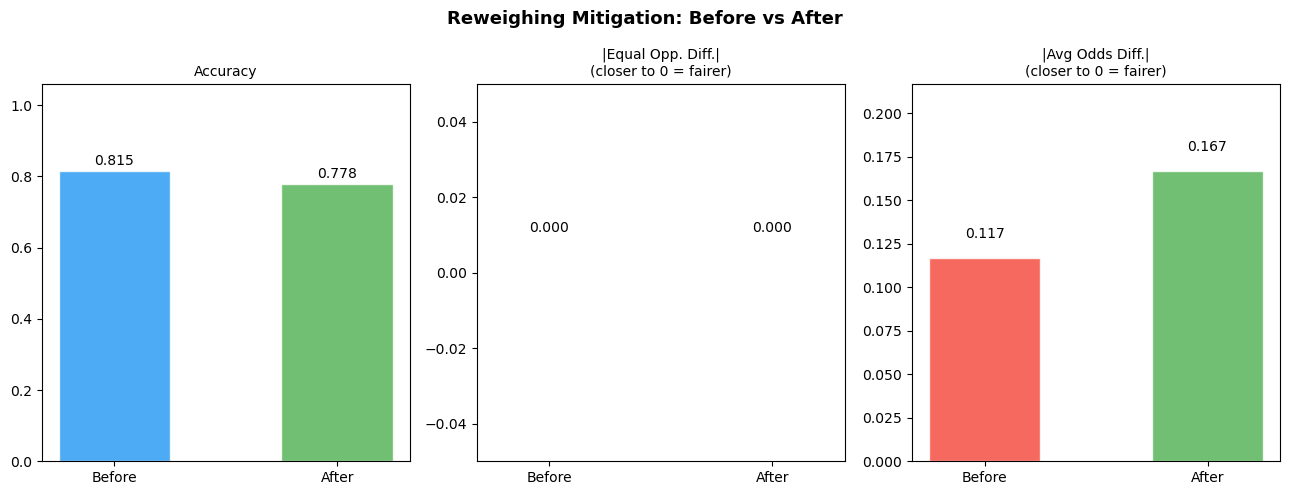

Accuracy:  0.815 -> 0.778
|EOD|:     0.000 -> 0.000
|AOD|:     0.117 -> 0.167


In [9]:
from aif360.algorithms.preprocessing import Reweighing

df_full = df[feature_cols + ['sex_binary', 'label']].copy()
aif_full = BinaryLabelDataset(df=df_full, label_names=['label'],
    protected_attribute_names=['sex_binary'], favorable_label=0, unfavorable_label=1)

RW = Reweighing(privileged_groups=privileged_groups, unprivileged_groups=unprivileged_groups)
aif_reweighed = RW.fit_transform(aif_full)

X_rw = aif_reweighed.features
y_rw = aif_reweighed.labels.ravel()
w_rw = aif_reweighed.instance_weights
X_rw_scaled = scaler.fit_transform(X_rw)

X_tr, X_te, y_tr, y_te, w_tr, _, idx_tr, idx_te = train_test_split(
    X_rw_scaled, y_rw, w_rw, df.index,
    test_size=0.3, random_state=42, stratify=y_rw
)

clf_rw = LogisticRegression(random_state=42, max_iter=500)
clf_rw.fit(X_tr, y_tr, sample_weight=w_tr)
y_pred_rw = clf_rw.predict(X_te)

df_test_rw = df.loc[idx_te][feature_cols + ['sex_binary', 'label']].copy()
df_pred_rw = df_test_rw.copy()
df_pred_rw['label'] = y_pred_rw

aif_test_rw = BinaryLabelDataset(df=df_test_rw, label_names=['label'],
    protected_attribute_names=['sex_binary'], favorable_label=0, unfavorable_label=1)
aif_pred_rw = BinaryLabelDataset(df=df_pred_rw, label_names=['label'],
    protected_attribute_names=['sex_binary'], favorable_label=0, unfavorable_label=1)

clf_metric_rw = ClassificationMetric(
    aif_test_rw, aif_pred_rw,
    privileged_groups=privileged_groups,
    unprivileged_groups=unprivileged_groups
)

# Compare before vs after
acc_before = accuracy_score(y_test, y_pred)
acc_after  = accuracy_score(y_te, y_pred_rw)
eod_before = abs(clf_metric.equal_opportunity_difference())
eod_after  = abs(clf_metric_rw.equal_opportunity_difference())
aod_before = abs(clf_metric.average_odds_difference())
aod_after  = abs(clf_metric_rw.average_odds_difference())

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle('Reweighing Mitigation: Before vs After', fontsize=13, fontweight='bold')

labels = ['Accuracy', '|Equal Opp. Diff.|\n(closer to 0 = fairer)', '|Avg Odds Diff.|\n(closer to 0 = fairer)']
befores = [acc_before, eod_before, aod_before]
afters  = [acc_after,  eod_after,  aod_after]
colors  = [['#2196F3', '#4CAF50'], ['#F44336', '#4CAF50'], ['#F44336', '#4CAF50']]

for i, (ax, label) in enumerate(zip(axes, labels)):
    bars = ax.bar(['Before', 'After'], [befores[i], afters[i]],
                  color=colors[i], alpha=0.8, width=0.5, edgecolor='white')
    ax.set_title(label, fontsize=10)
    ax.set_ylim(0, max(befores[i], afters[i]) * 1.3)
    for bar, val in zip(bars, [befores[i], afters[i]]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f'Accuracy:  {acc_before:.3f} -> {acc_after:.3f}')
print(f'|EOD|:     {eod_before:.3f} -> {eod_after:.3f}')
print(f'|AOD|:     {aod_before:.3f} -> {aod_after:.3f}')

### Ethical Checkpoint 4: Is mitigation enough?

Reweighing improved fairness metrics — but consider:

1. **The age confound is untouched.** Controls are still ~30 years younger. Reweighing by sex does not fix a structural data problem.

2. **The scanner quality gap is untouched.** 0.3T participants still have lower quality images. No algorithmic fix replaces better infrastructure.

3. **The sample is still n=88.** Improved metrics on a test set of ~26 participants are not reliable.

**The most meaningful interventions are upstream:**
- Longitudinal data collection with age-matched controls
- Higher-field MRI infrastructure investment in Africa  
- Community-driven data governance frameworks
- More datasets like this one

> *Fairness toolkits are diagnostic tools, not solutions.*

---

## Resources
- **brainlife.io:** https://brainlife.io
- **African Brain Data Network:** https://africanbraindatanetwork.com/
- **AI Fairness 360:** https://github.com/Trusted-AI/AIF360
- **OpenNeuro:** https://openneuro.org
- **Tutorial GitHub:** https://github.com/victoriamccray/Hackathon

## Generative AI Use Statement

Portions of the code in this notebook were developed with assistance from 
Claude (Anthropic), an AI assistant, as part of an iterative development 
process. All code was reviewed, tested, and validated by the author. 
AI assistance was used for code generation and debugging; all analytical 
decisions, ethical framing, and interpretations are the author's own.